In [25]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('./data/processed_newsgroups.csv')
df['processed_text'] = df['processed_text'].fillna('')
print(f"Total documents loaded: {len(df)}")

Total documents loaded: 19955


In [27]:
# mapping the 20 granular categories into the 6 parent categories
category_mapping = {
    # computers
    'comp.graphics': 'comp',
    'comp.os.ms-windows.misc': 'comp',
    'comp.sys.ibm.pc.hardware': 'comp',
    'comp.sys.mac.hardware': 'comp',
    'comp.windows.x': 'comp',
    
    # recreation
    'rec.autos': 'rec',
    'rec.motorcycles': 'rec',
    'rec.sport.baseball': 'rec',
    'rec.sport.hockey': 'rec',
    
    # science
    'sci.crypt': 'sci',
    'sci.electronics': 'sci',
    'sci.med': 'sci',
    'sci.space': 'sci',
    
    # miscellaneous
    'misc.forsale': 'misc',
    
    # politics
    'talk.politics.misc': 'politics',
    'talk.politics.guns': 'politics',
    'talk.politics.mideast': 'politics',
    
    # religion
    'talk.religion.misc': 'religion',
    'alt.atheism': 'religion',
    'soc.religion.christian': 'religion'
}

In [28]:
df['parent_label'] = df['label'].map(category_mapping) # create the new target column

print("\nClass Distribution for 6 Macro Categories:")
print(df['parent_label'].value_counts())


Class Distribution for 6 Macro Categories:
parent_label
comp        4980
sci         3995
rec         3993
politics    3000
religion    2996
misc         991
Name: count, dtype: int64


In [29]:
X_train_raw, X_test_raw, y_train_parent, y_test_parent, y_train_child, y_test_child = train_test_split(
    df['processed_text'], df['parent_label'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

In [30]:
cv = CountVectorizer(max_df=0.95, min_df=5)

X_train_counts = cv.fit_transform(X_train_raw)
X_test_counts = cv.transform(X_test_raw)

feature_names = cv.get_feature_names_out()

In [31]:
def compute_pmi(X_counts, y, top_k=1000):
    n_docs, n_words = X_counts.shape
    classes = np.unique(y)
    
    X_bin = (X_counts > 0).astype(int)
    
    word_counts = np.array(X_bin.sum(axis=0)).flatten()
    p_w = word_counts / n_docs
    
    pmi_scores = np.zeros(n_words)
    
    for c in classes:
        class_mask = (y == c).values
        n_c = np.sum(class_mask)
        
        p_c = n_c / n_docs
        
        X_c = X_bin[class_mask]
        word_counts_c = np.array(X_c.sum(axis=0)).flatten()
        p_w_c = word_counts_c / n_docs
        
        with np.errstate(divide='ignore'):
            pmi = np.log((p_w_c + 1e-9) / (p_w * p_c + 1e-9))
        
        pmi_scores = np.maximum(pmi_scores, pmi)
    
    top_indices = np.argsort(pmi_scores)[-top_k:]
    return top_indices

In [32]:
print("Training Parent Model...")

top_parent_features = compute_pmi(X_train_counts, y_train_parent, top_k=3000)

X_train_parent = X_train_counts[:, top_parent_features]
X_test_parent = X_test_counts[:, top_parent_features]

parent_classifier = MultinomialNB()
parent_classifier.fit(X_train_parent, y_train_parent)

Training Parent Model...


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [33]:
print("Training Child Expert Models...")

child_models = {}

for parent in y_train_parent.unique():

    mask = (y_train_parent == parent).values

    X_train_specific = X_train_counts[mask]
    y_train_specific = y_train_child[mask]

    top_child_features = compute_pmi(
        X_train_specific,
        y_train_specific,
        top_k=1000
    )

    X_train_child = X_train_specific[:, top_child_features]

    model = MultinomialNB()
    model.fit(X_train_child, y_train_specific)

    child_models[parent] = {'features': top_child_features, 'model': model}
    print(f"{parent} Classifier trained successfully!")

Training Child Expert Models...
sci Classifier trained successfully!
comp Classifier trained successfully!
politics Classifier trained successfully!
rec Classifier trained successfully!
religion Classifier trained successfully!
misc Classifier trained successfully!


In [34]:
print("Predicting...")

parent_preds = parent_classifier.predict(X_test_parent)

final_predictions = []

for i in range(X_test_counts.shape[0]):

    predicted_parent = parent_preds[i]

    expert = child_models[predicted_parent]

    features = expert['features']
    model = expert['model']

    doc = X_test_counts[i]
    doc_selected = doc[:, features]

    pred = model.predict(doc_selected)

    final_predictions.append(pred[0])

Predicting...


In [35]:
print("\nClassification Report: 6 CLASSES\n")

parent_acc = accuracy_score(y_test_parent, parent_preds)
print(f"Parent Accuracy: {parent_acc:.4f}\n")

print(classification_report(y_test_parent, parent_preds))


print("\nClassification Report: 20 SUB-CLASSES\n")

child_acc = accuracy_score(y_test_child, final_predictions)
print(f"Child Accuracy: {child_acc:.4f}\n")

print(classification_report(y_test_child, final_predictions))


Classification Report: 6 CLASSES

Parent Accuracy: 0.6334

              precision    recall  f1-score   support

        comp       0.46      0.89      0.60       995
        misc       0.69      0.44      0.54       198
    politics       0.84      0.74      0.79       600
         rec       0.97      0.51      0.67       799
    religion       0.84      0.84      0.84       599
         sci       0.53      0.26      0.35       800

    accuracy                           0.63      3991
   macro avg       0.72      0.61      0.63      3991
weighted avg       0.70      0.63      0.62      3991


Classification Report: 20 SUB-CLASSES

Child Accuracy: 0.3082

                          precision    recall  f1-score   support

             alt.atheism       0.00      0.00      0.00       200
           comp.graphics       0.09      0.85      0.16       199
 comp.os.ms-windows.misc       0.57      0.21      0.30       198
comp.sys.ibm.pc.hardware       0.00      0.00      0.00       199
  

/Users/manojith/Documents/002_Education/036_SLIIT_MSc_In_AI/2nd_Semester/IT5072_Natural_Language_Processing/003_Assignment/nlp-topic-identification/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/manojith/Documents/002_Education/036_SLIIT_MSc_In_AI/2nd_Semester/IT5072_Natural_Language_Processing/003_Assignment/nlp-topic-identification/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/manojith/Documents/002_Education/036_SLIIT_MSc_In_AI/2nd_Semester

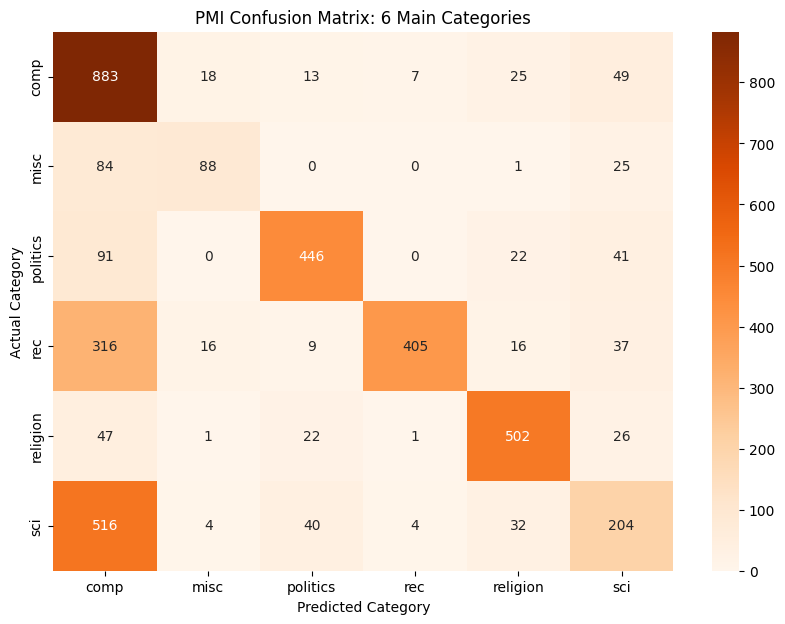

In [36]:
cm_pmi = confusion_matrix(y_test_parent, parent_preds)
labels = sorted(y_test_parent.unique())

plt.figure(figsize=(10, 7))

sns.heatmap(cm_pmi, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels)

plt.title('PMI Confusion Matrix: 6 Main Categories')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()